In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


sys.path.append('../')
from src_experiment.paths import outputs
from src_experiment.estimate_quantities import ExperimentEvaluator

In [2]:
# Define path
def get_path(noise, architecture, seed):
    return outputs / F"wbc_label_noise/n{noise}_{architecture}/seed_{int(seed)}.h5"

get_path(0.0, "[5,5,5]", seed=101)

PosixPath('/home/johan/Documents/phd/WP1/geometric_binning_estimator/outputs/wbc_label_noise/n0.0_[5,5,5]/seed_101.h5')

In [3]:

def get_mean_MI(noise, architecture, seeds=[101,102,103,104,105]):
    # Should return the Mi for all epochs for all paths, and the average across all paths
    MIs = {}
    for seed in seeds:
        path = get_path(noise, architecture, seed)
        ev = ExperimentEvaluator(path)
        df_results = ev.evaluate_all()
        MIs["epoch"] = df_results["epoch"].values if "epoch" not in MIs else MIs["epoch"]
        MIs["layer_idx"] = df_results["layer_idx"].values if "layer_idx" not in MIs else MIs["layer_idx"]
        MIs[f"I(Y;W)_seed_{seed}"] = df_results["I(Y;W)"].values
        MIs[f"I(X;W)_seed_{seed}"] = df_results["I(X;W)"].values
    # Now calculate the mean across seeds for each epoch and layer
    MI_mean = {}
    MIs["I(Y;W)_mean"] = np.mean([MIs[f"I(Y;W)_seed_{seed}"] for seed in seeds], axis=0)
    MIs["I(X;W)_mean"] = np.mean([MIs[f"I(X;W)_seed_{seed}"] for seed in seeds], axis=0)
    MI_mean["epoch"] = MIs["epoch"]
    MI_mean["layer_idx"] = MIs["layer_idx"]
    MI_mean["I(Y;W)"] = MIs["I(Y;W)_mean"]
    MI_mean["I(X;W)"] = MIs["I(X;W)_mean"]
    return pd.DataFrame(MIs), pd.DataFrame(MI_mean)

In [4]:

full_df, mean_df = get_mean_MI(0.0, "[5, 5, 5]")

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

In [5]:
full_df

,epoch,layer_idx,I(Y;W)_seed_101,I(X;W)_seed_101,I(Y;W)_seed_102,I(X;W)_seed_102,I(Y;W)_seed_103,I(X;W)_seed_103,I(Y;W)_seed_104,I(X;W)_seed_104,I(Y;W)_seed_105,I(X;W)_seed_105,I(Y;W)_mean,I(X;W)_mean
0,0,1,0.408690,2.310098,0.195730,1.595611,0.195245,2.011019,0.279179,1.460391,0.629995,1.871487,0.341768,1.849721
1,0,2,0.458296,2.665063,0.203170,1.669470,0.318709,3.343347,0.378507,2.177268,0.716194,3.591958,0.414975,2.689421
2,0,3,0.486345,3.417007,0.203170,1.669470,0.390190,4.129746,0.378507,2.177268,0.734981,3.628289,0.438639,3.004356
3,0,4,0.509596,3.676116,0.203170,1.669470,0.428169,4.308076,0.397294,2.213598,0.745027,3.680921,0.456651,3.109636
4,1,1,0.374153,2.288400,0.195730,1.595611,0.155576,1.838267,0.279179,1.460391,0.540220,1.966290,0.308972,1.829792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,140,4,0.852446,4.021850,0.797953,3.394688,0.845065,4.253116,0.871981,3.045743,0.907044,3.278551,0.854898,3.598789
84,150,1,0.410879,2.000714,0.439538,2.126441,0.330505,2.156857,0.240419,1.207792,0.607486,2.714377,0.405765,2.041236
85,150,2,0.822927,3.177270,0.471273,2.252973,0.445138,3.044602,0.751441,2.359916,0.767166,3.124899,0.651589,2.791932
86,150,3,0.822927,3.669871,0.702021,3.241910,0.765297,3.830797,0.778657,2.743871,0.767166,3.226163,0.767214,3.342523


In [11]:
import pandas as pd

# Define the lists of what you want to plot
architectures = ["[5, 5, 5]", "[15, 15, 15]", "[50, 50, 50]"] # Replace with your actual architecture names
noise_levels = [0.0, 0.2, 0.4]

all_data = []

# Loop through every combination of architecture and noise
for arch in architectures:
    for noise in noise_levels:
        
        # Call your function. We use [1] to grab the MI_mean dataframe
        df_mean = get_mean_MI(noise, arch)[1].copy()
        
        # INJECT THE MISSING METADATA COLUMNS HERE
        df_mean['architecture'] = arch
        df_mean['label_noise'] = noise 
        
        # Append to our master list
        all_data.append(df_mean)

# Combine everything into one massive DataFrame
combined_df = pd.concat(all_data, ignore_index=True)

# Filter for just the first 3 layers (optional, but recommended for clarity)
unique_layers = sorted(combined_df['layer_idx'].unique())
layers_to_keep = unique_layers[:3]
combined_df = combined_df[combined_df['layer_idx'].isin(layers_to_keep)]

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

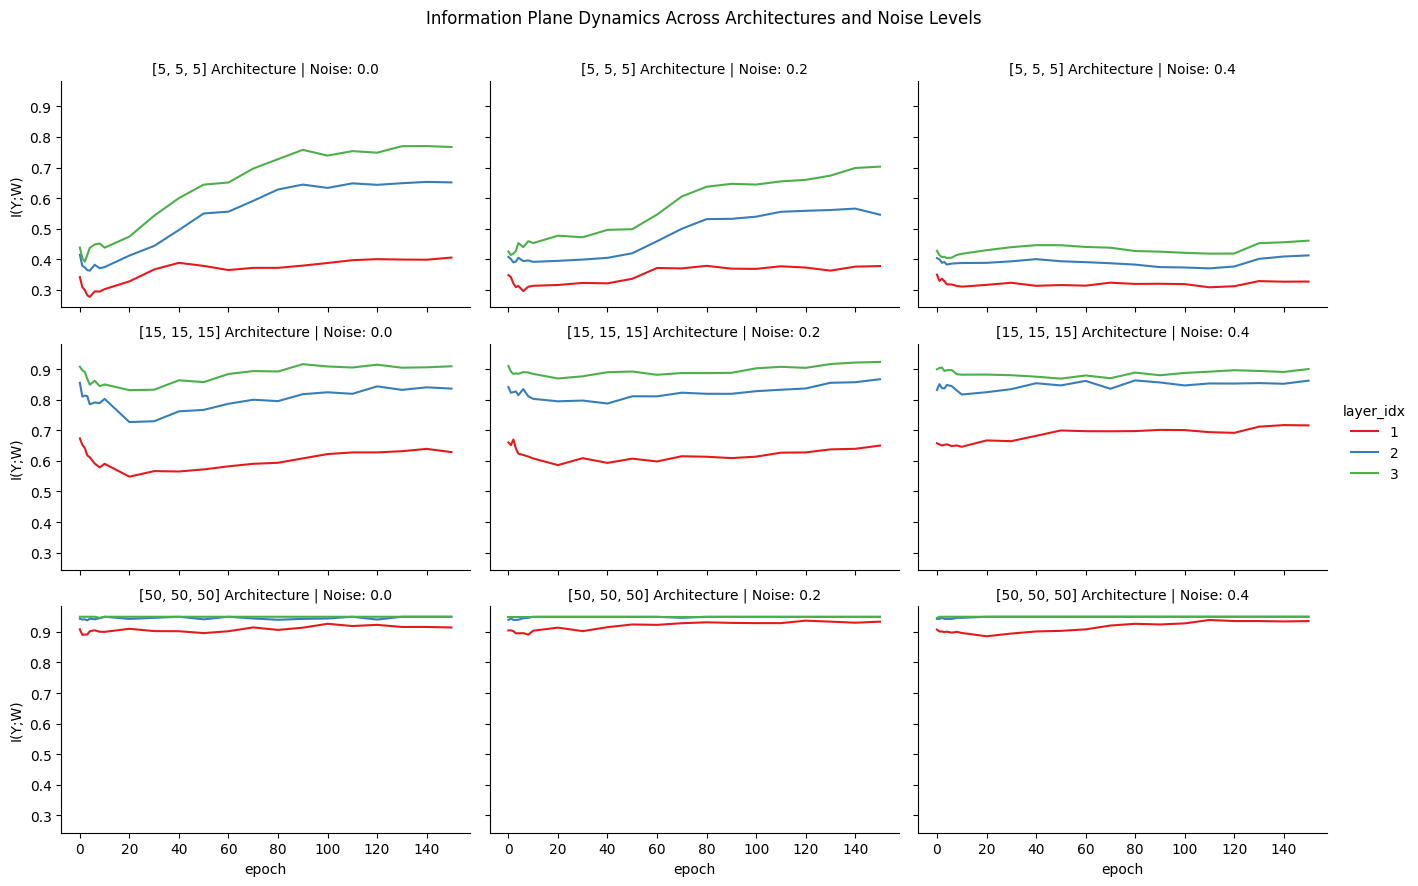

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'combined_df' has all your data for all architectures, noises, and layers

g = sns.relplot(
    data=combined_df,
    x="epoch",
    y="I(Y;W)",
    hue="layer_idx",       # Different colors for layers
    col="label_noise",     # Different columns for noise levels
    row="architecture",    # Different rows for architectures
    kind="line",
    palette="Set1",
    height=3,              # Height of each individual subplot
    aspect=1.5             # Width-to-height ratio of each subplot
)

# Clean up the titles
g.set_titles(row_template="{row_name} Architecture", col_template="Noise: {col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Information Plane Dynamics Across Architectures and Noise Levels")

plt.show()

In [6]:
# import matplotlib.pyplot as plt
# import seaborn as sns

def plot_label_noise(architecture):
    noise_levels = [0.0, 0.2, 0.4]

    # Set up the figure with 1 row and 3 columns, sharing the y-axis
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), sharey=True)

    # Choose a distinct color palette
    # Other good options: "Set1", "Set2", "Dark2", or "husl"
    my_palette = "tab10" 

    for i, (ax, noise) in enumerate(zip(axes, noise_levels)):
        df = get_mean_MI(noise, architecture)[1]
        
        # Add the palette argument here
        sns.lineplot(
            data=df, 
            x="epoch", 
            y="I(Y;W)", 
            hue="layer_idx", 
            palette=my_palette, 
            ax=ax
        )
        
        ax.set_title(f"Label Noise = {noise}")
        
        # Clean up the legends
        if i < 2:
            ax.get_legend().remove()
        else:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Layer Index")
    fig.suptitle(f"WBC dataset with {architecture} arcitecture")
    plt.tight_layout()
    plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_label_noise(architecture):
    noise_levels = [0.0, 0.2, 0.4]
    all_data = []

    # 1. Fetch and combine data for all noise levels
    for noise in noise_levels:
        # Use .copy() to avoid SettingWithCopyWarning
        df = get_mean_MI(noise, architecture)[1].copy() 
        # Add a column for noise level, formatted as string for discrete styling
        df['label_noise'] = f"{noise}" 
        all_data.append(df)
        
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # 2. Filter for the first three layers (excluding the last one)
    # Sorting ensures we get them in the correct sequential order (e.g., 0, 1, 2)
    unique_layers = sorted(combined_df['layer_idx'].unique())
    layers_to_keep = unique_layers[:3] 
    filtered_df = combined_df[combined_df['layer_idx'].isin(layers_to_keep)]

    # 3. Set up a single figure
    fig, ax = plt.subplots(figsize=(10, 6))
    my_palette = "tab10" 

    # 4. Plot on the single axis mapping hue to layer and style to noise
    sns.lineplot(
        data=filtered_df, 
        x="epoch", 
        y="I(Y;W)", 
        hue="layer_idx",       # Different colors for different layers
        style="label_noise",   # Different line styles for different noise levels
        palette=my_palette, 
        ax=ax
    )
    
    ax.set_title(f"WBC dataset with {architecture} architecture")
    
    # Clean up the legend, moving it outside the plot so it doesn't overlap the lines
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

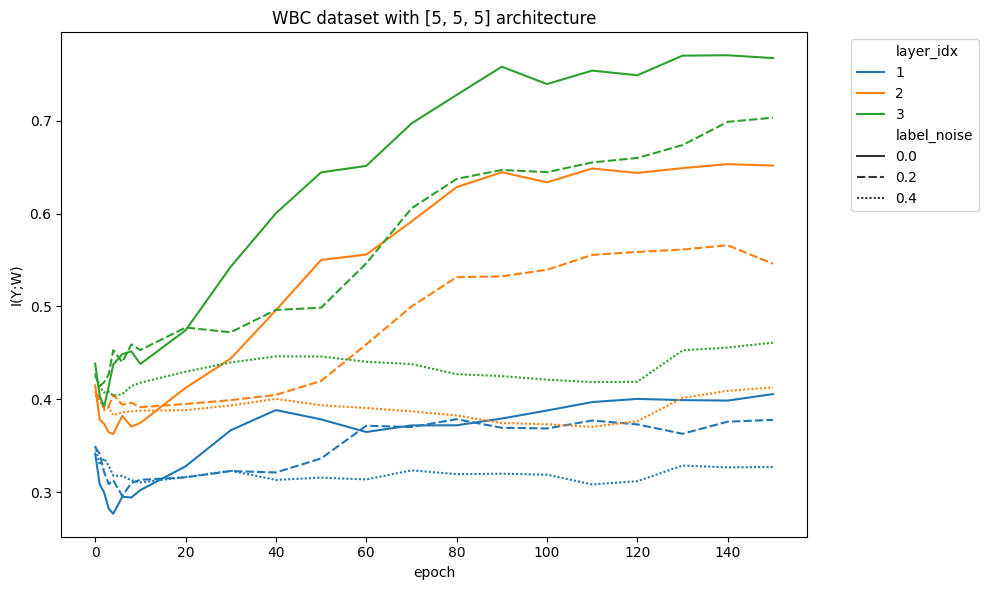

In [8]:
plot_label_noise("[5, 5, 5]")

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

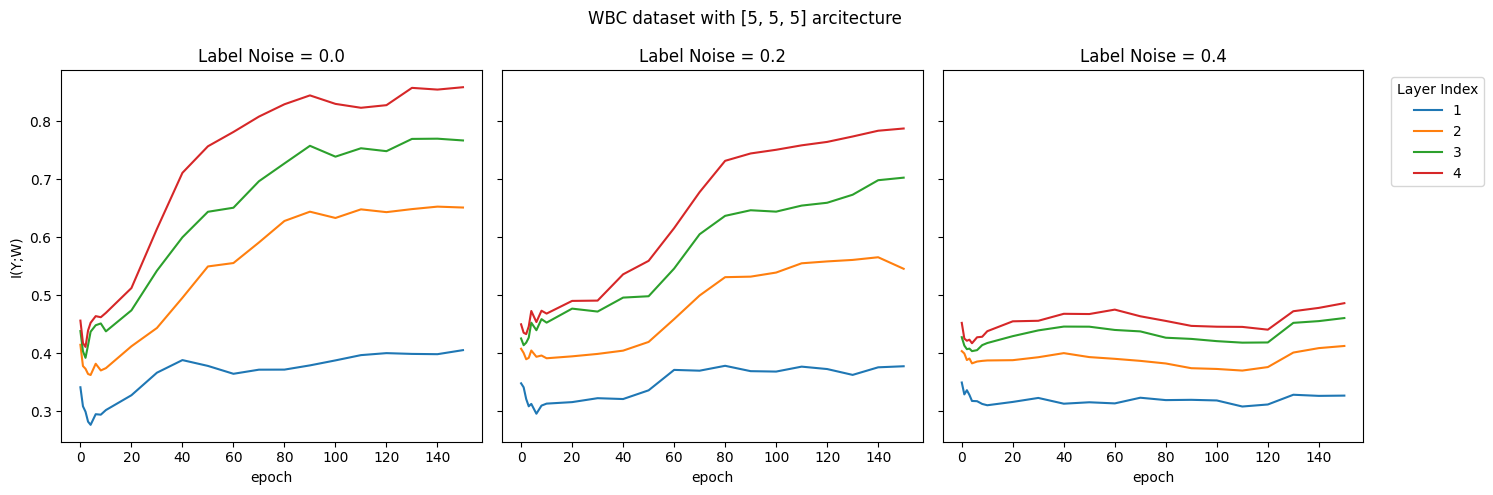

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

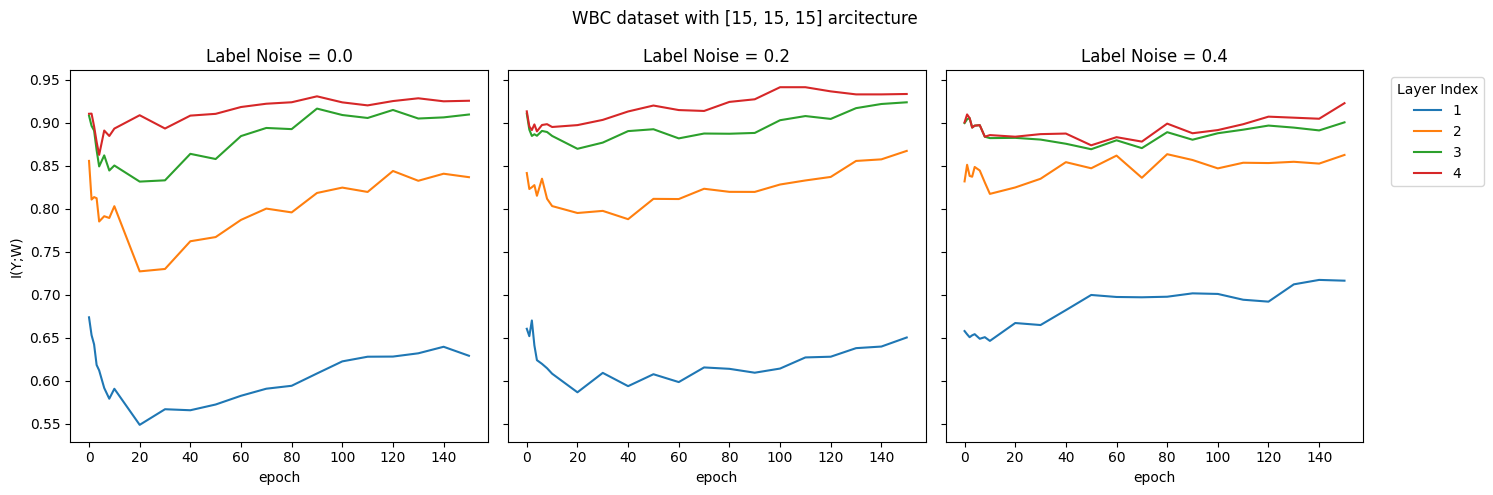

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

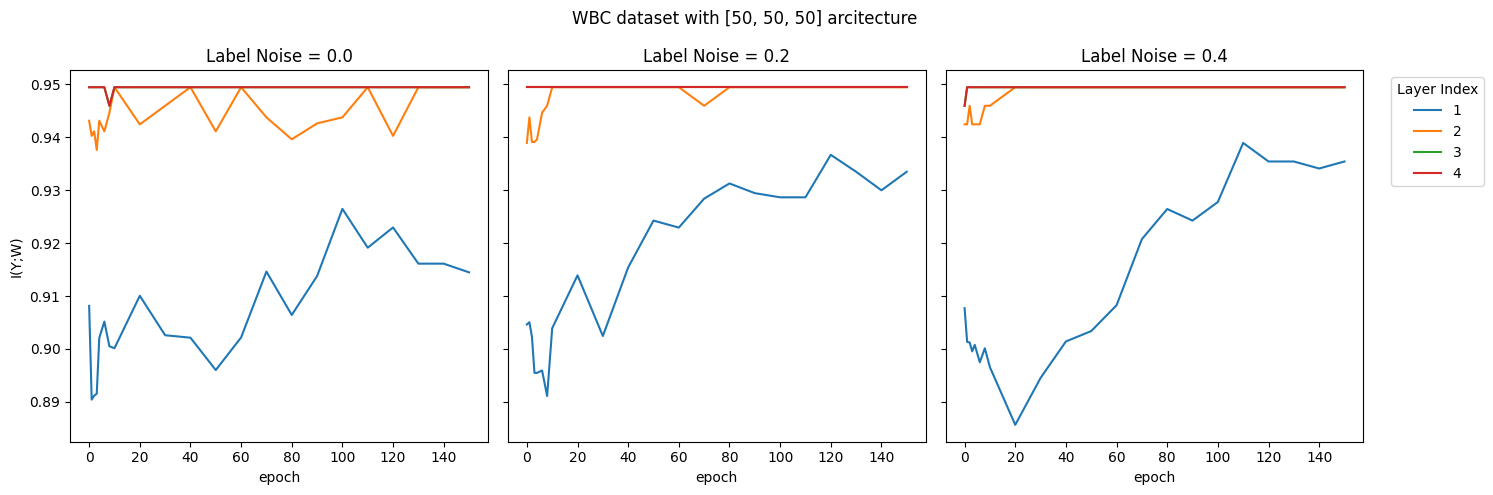

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

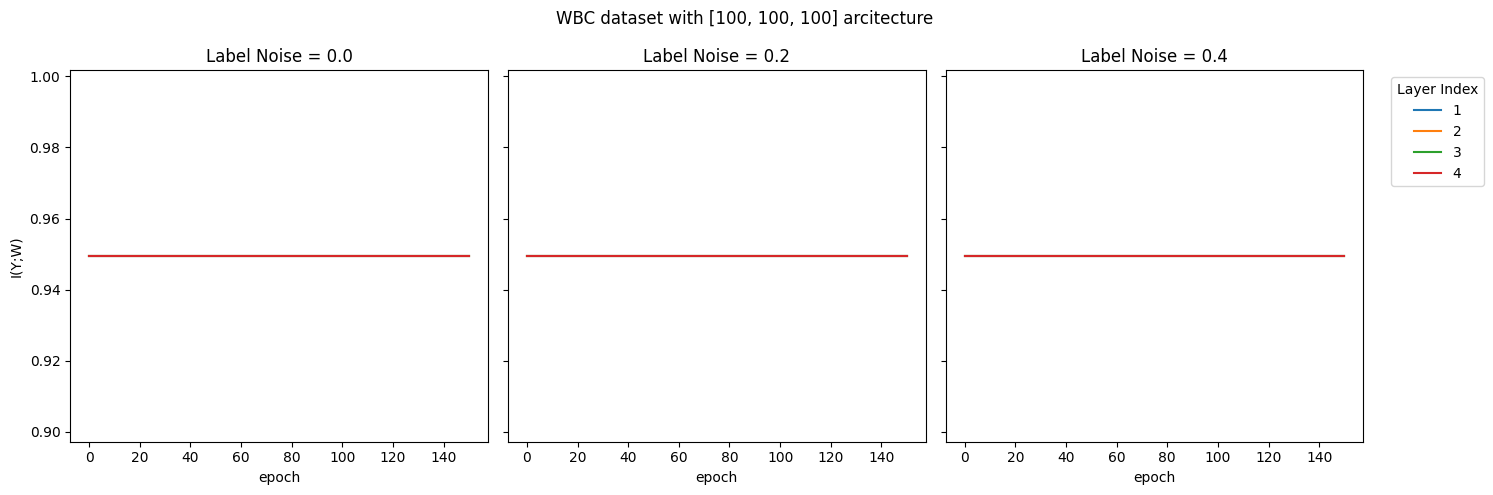

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

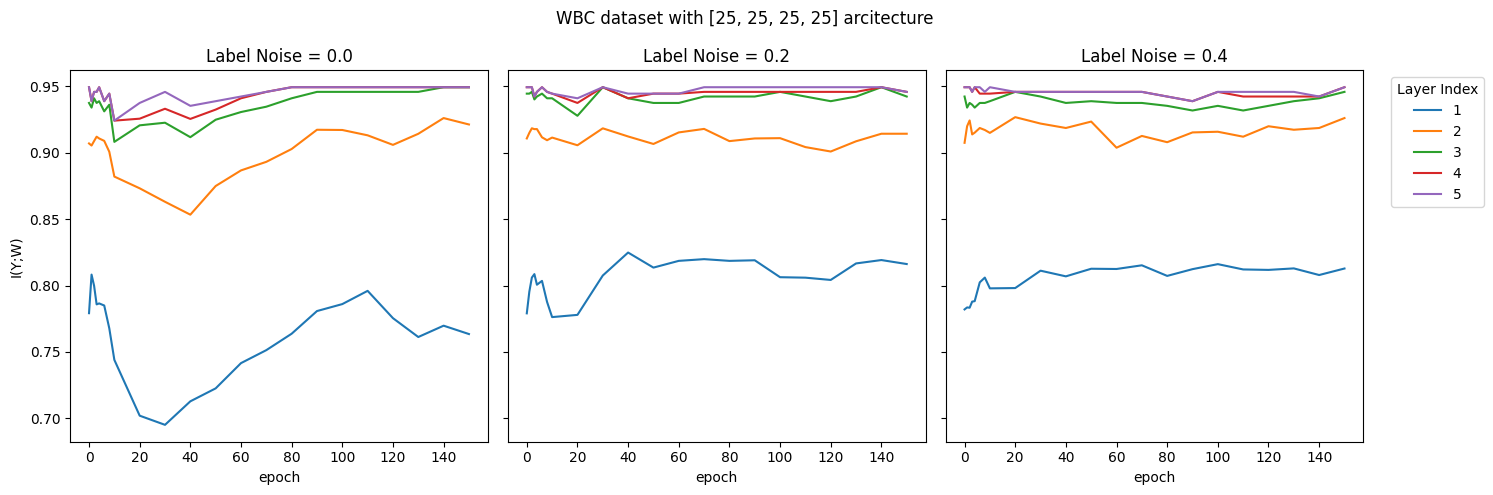

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

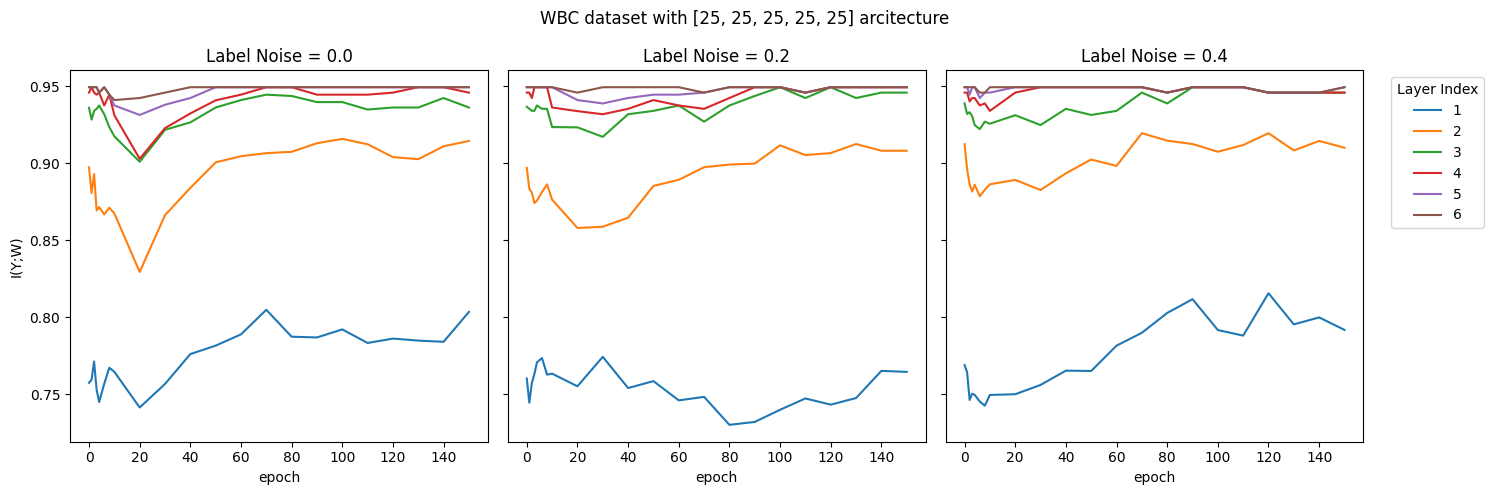

In [ ]:
arches = [
    "[5, 5, 5]",
    "[15, 15, 15]", 
    "[50, 50, 50]",
    "[100, 100, 100]", 
    "[25, 25, 25, 25]",
    "[25, 25, 25, 25, 25]"
]

# for arch in arches:
#     plot_label_noise(arch)

In [41]:
from scipy.stats import entropy
path = get_path(0.0, "[5, 5, 5]", 101)
ev = ExperimentEvaluator(path)
df_results = ev.evaluate_all()


# 1. Calculate H(X) bound (Data Entropy / Max Memorization)
# Since every point is assumed uniform, H(X) = log2(N)
H_X = np.log2(ev.N_total)

# 2. Calculate H(Y) bound (Label Entropy / Max Prediction)
# Find the distribution of your classes
_, counts = np.unique(ev.labels, return_counts=True)
probabilities = counts / counts.sum()
H_Y = entropy(probabilities, base=2)

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

In [43]:
print(f"H(X): {H_X:.2f}")
print(f"H(Y): {H_Y:.2f}")


H(X): 6.83
H(Y): 0.95


Running grid search for d_x = 2...
Running grid search for d_x = 5...
Running grid search for d_x = 10...
Running grid search for d_x = 20...
Running grid search for d_x = 150...
Running grid search for d_x = 500...


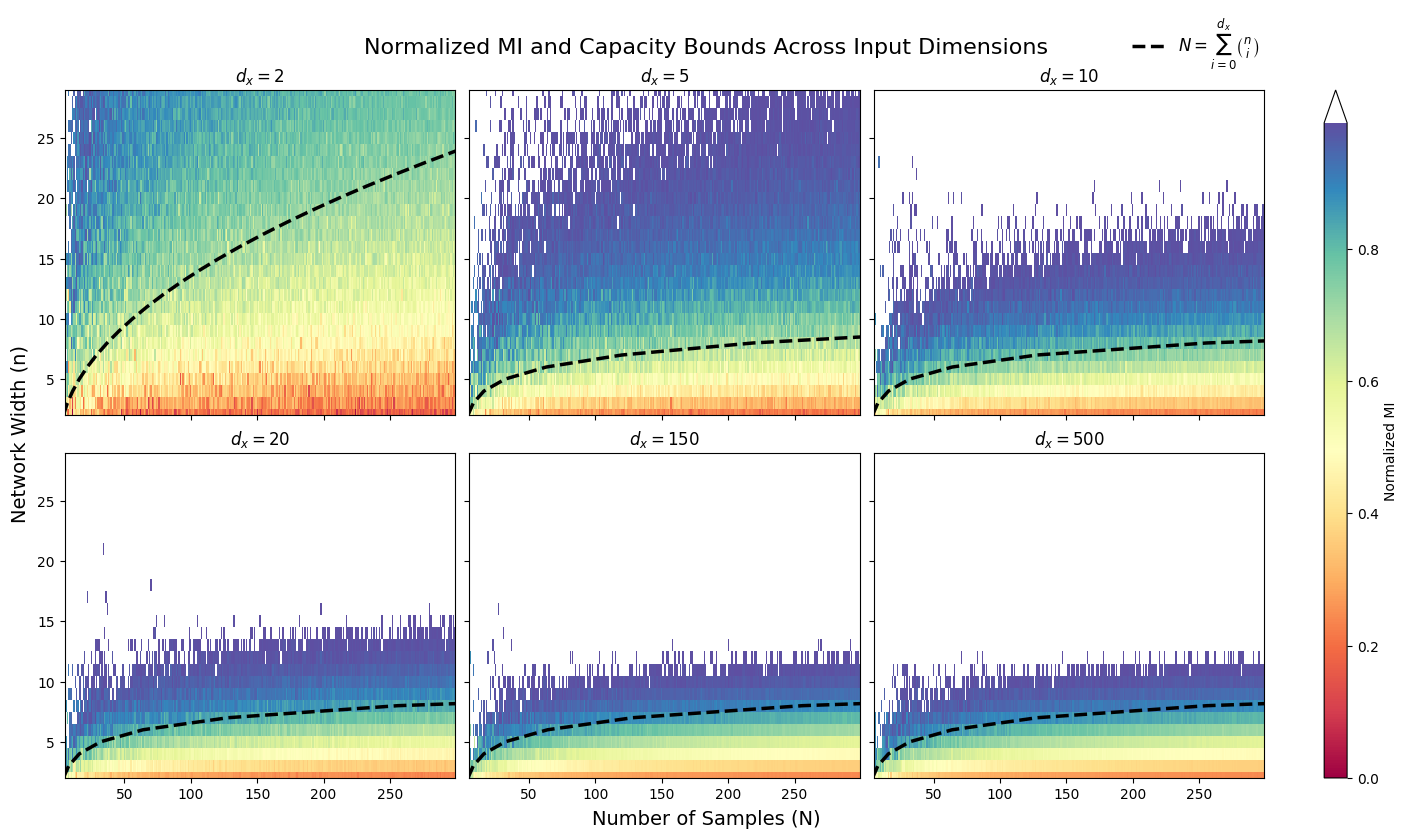

In [91]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def get_normalized_mi(X, model):
    """
    Passes data X through a single-layer network to get activation patterns,
    and calculates the normalized Mutual Information I(X;T) / H(X).
    """
    with torch.no_grad():
        Z = model(X)
        T = (Z > 0).int().numpy()
        
    unique_patterns, counts = np.unique(T, axis=0, return_counts=True)
    probabilities = counts / np.sum(counts)
    H_T = entropy(probabilities, base=2)
    
    N = X.shape[0]
    H_X = np.log2(N)
    
    return H_T / H_X if H_X > 0 else 0.0

def run_experiment_1(dx=2, ax=None):
    d_x = dx  
    N_values = np.arange(5, 300, 1)        
    dn_values = np.arange(2, 30, 1)        
    
    mi_matrix = np.zeros((len(dn_values), len(N_values)))
    
    print(f"Running grid search for d_x = {d_x}...")
    
    for i, d_n in enumerate(dn_values):
        for j, N in enumerate(N_values):
            X = torch.randn(N, d_x)
            layer = nn.Linear(d_x, d_n)
            mi_matrix[i, j] = get_normalized_mi(X, layer)
            
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    X_mesh, Y_mesh = np.meshgrid(N_values, dn_values)
    
    cmap = plt.colormaps['Spectral'].copy() 
    cmap.set_over('white') 
    
    cp = ax.pcolormesh(
        X_mesh, 
        Y_mesh, 
        mi_matrix, 
        shading='auto', 
        cmap=cmap, 
        vmin=0.0, 
        vmax=0.99
    )
    
    N_bound = []
    for n in dn_values:
        bound = sum(math.comb(n, i) for i in range(min(n + 1, d_x + 1)))
        N_bound.append(bound)
        
    ax.plot(
        N_bound, 
        dn_values, 
        color='black', 
        linestyle='--', 
        linewidth=2.5, 
        label=r'$N = \sum_{i=0}^{d_x} \binom{n}{i}$'
    )
    
    ax.set_xlim(N_values.min(), N_values.max())
    ax.set_ylim(dn_values.min(), dn_values.max())
    
    # Set a cleaner, smaller title for each subplot
    ax.set_title(f'$d_x={d_x}$')
    
    # Return the colormap object so the main script can build a global colorbar
    return cp

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    dx_values = [2, 5, 10, 20, 150, 500]  
    
    # Added sharex, sharey, and constrained layout
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True, layout="constrained")
    axes_flat = axes.flatten()

    # Store the colormap from the last run
    cp = None
    for ax, dx in zip(axes_flat, dx_values): 
        cp = run_experiment_1(dx=dx, ax=ax)
        
    # --- GLOBAL STYLING ---
    
    # 1. Single Global Axis Labels
    fig.supxlabel('Number of Samples (N)', fontsize=14)
    fig.supylabel('Network Width (n)', fontsize=14)
    fig.suptitle('Normalized MI and Capacity Bounds Across Input Dimensions', fontsize=16)

    # 2. Single Global Colorbar spanning the axes
    # We pass ax=axes so Matplotlib knows to scale it alongside the grid
    cbar = fig.colorbar(cp, ax=axes, label='Normalized MI', extend='max', aspect=30)

    # 3. Single Global Legend
    # Extract the line handle and label from the first subplot to avoid duplicates
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.85, 1.04), frameon=False, fontsize=12)

    plt.show()

In [93]:
class TrackingMLP(nn.Module):
    """An MLP that returns the concatenated activation pattern of ALL layers."""
    def __init__(self, d_in, d_n, L):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(d_in, d_n))
        for _ in range(L - 1):
            self.layers.append(nn.Linear(d_n, d_n))
            
    def forward(self, x):
        patterns = []
        out = x
        for i, layer in enumerate(self.layers):
            # Pre-activation
            out = layer(out)
            
            # Record the binary pattern for this specific layer
            patterns.append((out > 0).int().numpy())
            
            # Apply ReLU for all but the final layer
            if i < len(self.layers) - 1:
                out = torch.relu(out)
                
        # Concatenate horizontally: a point's region is defined by ALL layers combined
        global_pattern = np.concatenate(patterns, axis=1)
        return global_pattern

def get_normalized_mi_deep(X, model):
    """Updated to work directly with the concatenated global patterns."""
    with torch.no_grad():
        # The model now directly outputs the full Nx(L*d_n) binary matrix
        T = model(X)
        
    unique_patterns, counts = np.unique(T, axis=0, return_counts=True)
    
    probabilities = counts / np.sum(counts)
    H_T = entropy(probabilities, base=2)
    
    N = X.shape[0]
    H_X = np.log2(N)
    
    return H_T / H_X if H_X > 0 else 0.0

Running grid search for d_x = 2, L = 3...
Running grid search for d_x = 5, L = 3...
Running grid search for d_x = 10, L = 3...
Running grid search for d_x = 20, L = 3...
Running grid search for d_x = 150, L = 3...
Running grid search for d_x = 500, L = 3...


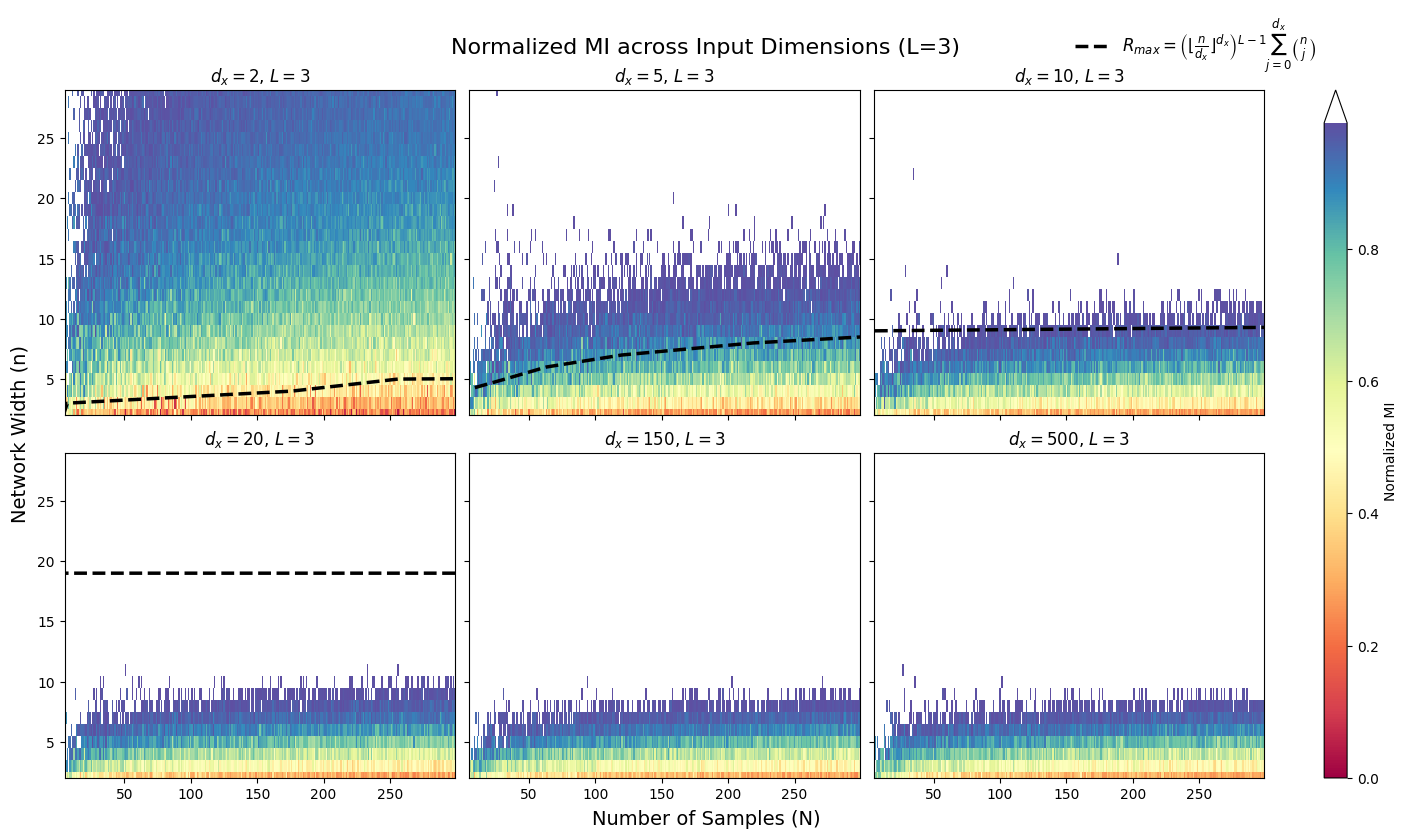

In [94]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def get_normalized_mi(X, model):
    """
    Passes data X through a network to get activation patterns of the FINAL layer,
    and calculates the normalized Mutual Information I(X;T) / H(X).
    """
    with torch.no_grad():
        Z = model(X)
        T = (Z > 0).int().numpy()
        
    unique_patterns, counts = np.unique(T, axis=0, return_counts=True)
    probabilities = counts / np.sum(counts)
    H_T = entropy(probabilities, base=2)
    
    N = X.shape[0]
    H_X = np.log2(N)
    
    return H_T / H_X if H_X > 0 else 0.0

def create_mlp(d_in, d_n, L):
    """Creates an MLP with L linear layers of width d_n, separated by ReLUs."""
    if L == 1:
        return nn.Linear(d_in, d_n)
    
    modules = [nn.Linear(d_in, d_n), nn.ReLU()]
    for _ in range(L - 2):
        modules.append(nn.Linear(d_n, d_n))
        modules.append(nn.ReLU())
    modules.append(nn.Linear(d_n, d_n)) # Final pre-activations
    
    return nn.Sequential(*modules)

def run_experiment_1(dx=2, L=2, ax=None):
    d_x = dx  
    N_values = np.arange(5, 300, 1)        
    dn_values = np.arange(2, 30, 1)        
    
    mi_matrix = np.zeros((len(dn_values), len(N_values)))
    
    print(f"Running grid search for d_x = {d_x}, L = {L}...")
    
    for i, d_n in enumerate(dn_values):
        for j, N in enumerate(N_values):
            X = torch.randn(N, d_x)
            model = TrackingMLP(d_x, d_n, L)
            mi_matrix[i, j] = get_normalized_mi_deep(X, model)
            
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    X_mesh, Y_mesh = np.meshgrid(N_values, dn_values)
    
    cmap = plt.colormaps['Spectral'].copy() 
    cmap.set_over('white') 
    
    cp = ax.pcolormesh(
        X_mesh, 
        Y_mesh, 
        mi_matrix, 
        shading='auto', 
        cmap=cmap, 
        vmin=0.0, 
        vmax=0.99
    )
    
    # --- UPDATED THEORETICAL BOUNDARY LOGIC ---
    N_bound = []
    for n in dn_values:
        # 1. The summation part (Schläfli sum for the final layer)
        sum_part = sum(math.comb(n, j) for j in range(min(n + 1, d_x + 1)))
        
        # 2. The exponential depth multiplier for L > 1
        if L > 1:
            multiplier = (math.floor(n / d_x) ** d_x) ** (L - 1)
        else:
            multiplier = 1 # Reverts to standard single-layer formula
            
        bound = multiplier * sum_part
        N_bound.append(bound)
        
    # Dynamically format the label string based on the number of layers
    if L > 1:
        label_str = r'$R_{max} = \left(\lfloor \frac{n}{d_x} \rfloor^{d_x}\right)^{L-1} \sum_{j=0}^{d_x} \binom{n}{j}$'
    else:
        label_str = r'$R_{max} = \sum_{j=0}^{d_x} \binom{n}{j}$'
        
    ax.plot(
        N_bound, 
        dn_values, 
        color='black', 
        linestyle='--', 
        linewidth=2.5, 
        label=label_str
    )
    
    ax.set_xlim(N_values.min(), N_values.max())
    ax.set_ylim(dn_values.min(), dn_values.max())
    ax.set_title(f'$d_x={d_x}$, $L={L}$')
    
    return cp

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    dx_values = [2, 5, 10, 20, 150, 500]  
    L_val = 3 # Let's test it with a 3-layer network
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True, layout="constrained")
    axes_flat = axes.flatten()

    cp = None
    for ax, dx in zip(axes_flat, dx_values): 
        # Pass L into the experiment
        cp = run_experiment_1(dx=dx, L=L_val, ax=ax)
        
    fig.supxlabel('Number of Samples (N)', fontsize=14)
    fig.supylabel('Network Width (n)', fontsize=14)
    
    # Updated global title
    fig.suptitle(f'Normalized MI across Input Dimensions (L={L_val})', fontsize=16)

    cbar = fig.colorbar(cp, ax=axes, label='Normalized MI', extend='max', aspect=30)

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.85, 1.04), frameon=False, fontsize=12)

    plt.show()

Running grid search for d_x = 2, L = 5...
Running grid search for d_x = 5, L = 5...
Running grid search for d_x = 10, L = 5...
Running grid search for d_x = 20, L = 5...
Running grid search for d_x = 150, L = 5...
Running grid search for d_x = 500, L = 5...


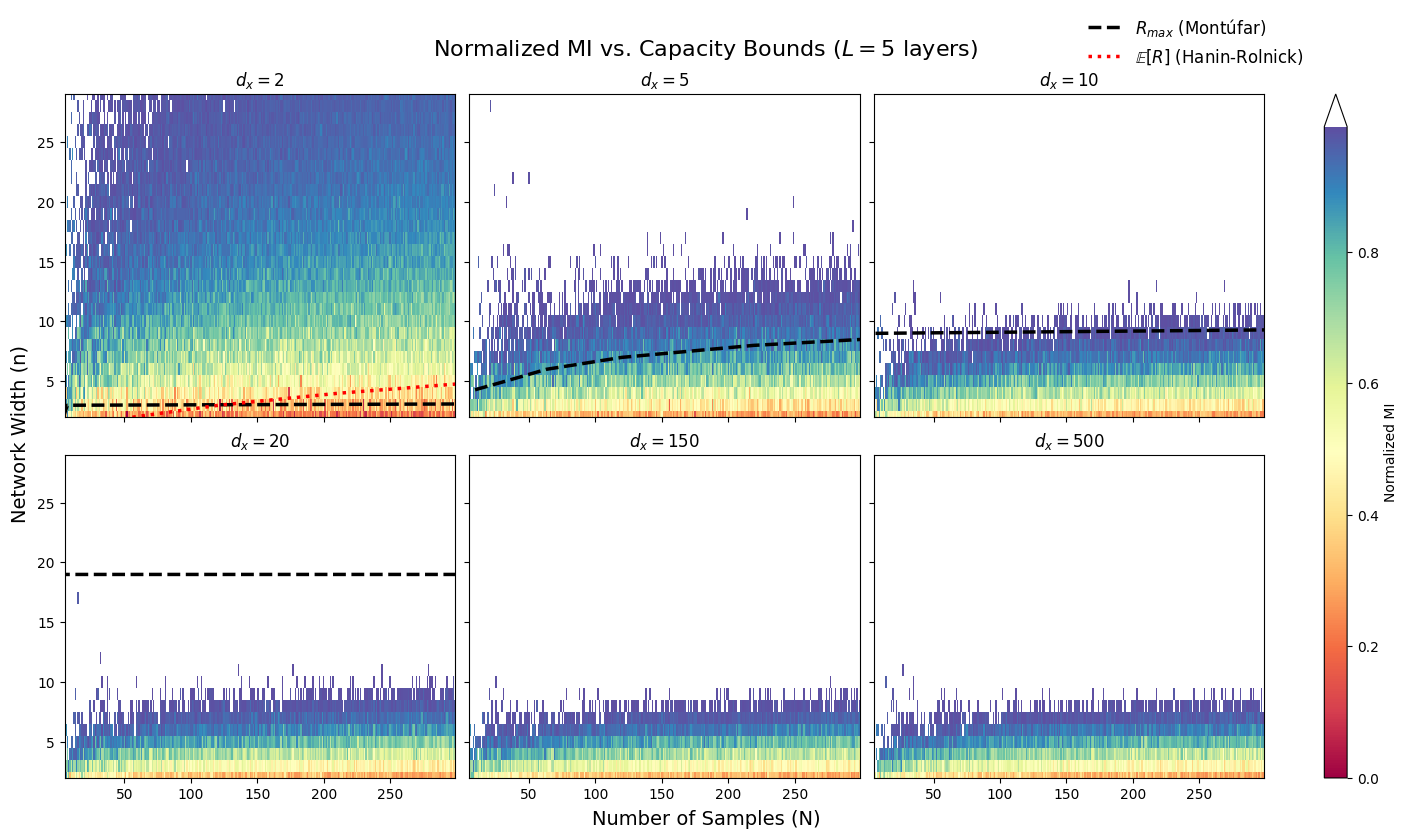

In [96]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

class TrackingMLP(nn.Module):
    """An MLP that returns the concatenated activation pattern of ALL layers."""
    def __init__(self, d_in, d_n, L):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(d_in, d_n))
        for _ in range(L - 1):
            self.layers.append(nn.Linear(d_n, d_n))
            
    def forward(self, x):
        patterns = []
        out = x
        for i, layer in enumerate(self.layers):
            out = layer(out)
            # Record the binary pattern for this specific layer
            patterns.append((out > 0).int())
            
            # Apply ReLU for all but the final layer
            if i < len(self.layers) - 1:
                out = torch.relu(out)
                
        # Concatenate horizontally and convert to numpy
        return torch.cat(patterns, dim=1).numpy()

def get_normalized_mi_deep(X, model):
    """Calculates MI using the concatenated global patterns from all layers."""
    with torch.no_grad():
        T = model(X)
        
    unique_patterns, counts = np.unique(T, axis=0, return_counts=True)
    probabilities = counts / np.sum(counts)
    H_T = entropy(probabilities, base=2)
    
    N = X.shape[0]
    H_X = np.log2(N)
    
    return H_T / H_X if H_X > 0 else 0.0

def run_experiment_1(dx=2, L=2, ax=None):
    d_x = dx  
    N_values = np.arange(5, 300, 1)        
    dn_values = np.arange(2, 30, 1)        
    
    mi_matrix = np.zeros((len(dn_values), len(N_values)))
    
    print(f"Running grid search for d_x = {d_x}, L = {L}...")
    
    for i, d_n in enumerate(dn_values):
        for j, N in enumerate(N_values):
            X = torch.randn(N, d_x)
            model = TrackingMLP(d_x, d_n, L)
            mi_matrix[i, j] = get_normalized_mi_deep(X, model)
            
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    X_mesh, Y_mesh = np.meshgrid(N_values, dn_values)
    
    cmap = plt.colormaps['Spectral'].copy() 
    cmap.set_over('white') 
    
    cp = ax.pcolormesh(
        X_mesh, 
        Y_mesh, 
        mi_matrix, 
        shading='auto', 
        cmap=cmap, 
        vmin=0.0, 
        vmax=0.99
    )
    
    # --- CALCULATE BOUNDARIES ---
    N_bound_max = []
    N_bound_expected = []
    
    for n in dn_values:
        # 1. Montúfar Maximum Bound (R_max)
        sum_part = sum(math.comb(n, j) for j in range(min(n + 1, d_x + 1)))
        multiplier = (math.floor(n / d_x) ** d_x) ** (L - 1) if L > 1 else 1
        N_bound_max.append(multiplier * sum_part)
        
        # 2. Hanin-Rolnick Expected Bound (E[R])
        N_total = L * n
        expected_bound = sum(math.comb(N_total, i) for i in range(min(N_total + 1, d_x + 1)))
        N_bound_expected.append(expected_bound)
        
    # --- PLOT BOUNDARIES ---
    
    # R_max (Theoretical Maximum - Black Dashed)
    label_max = r'$R_{max}$ (Montúfar)' if L > 1 else r'$R_{max} = \sum_{j=0}^{d_x} \binom{n}{j}$'
    ax.plot(N_bound_max, dn_values, color='black', linestyle='--', linewidth=2.5, label=label_max)
    
    # E[R] (Expected - Red Dotted)
    ax.plot(N_bound_expected, dn_values, color='red', linestyle=':', linewidth=2.5, label=r'$\mathbb{E}[R]$ (Hanin-Rolnick)')
    
    ax.set_xlim(N_values.min(), N_values.max())
    ax.set_ylim(dn_values.min(), dn_values.max())
    ax.set_title(f'$d_x={d_x}$')
    
    return cp

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    dx_values = [2, 5, 10, 20, 150, 500]  
    L_val = 5 
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True, layout="constrained")
    axes_flat = axes.flatten()

    cp = None
    for ax, dx in zip(axes_flat, dx_values): 
        cp = run_experiment_1(dx=dx, L=L_val, ax=ax)
        
    fig.supxlabel('Number of Samples (N)', fontsize=14)
    fig.supylabel('Network Width (n)', fontsize=14)
    fig.suptitle(f'Normalized MI vs. Capacity Bounds ($L={L_val}$ layers)', fontsize=16)

    cbar = fig.colorbar(cp, ax=axes, label='Normalized MI', extend='max', aspect=30)

    # Extract handles for the global legend
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.85, 1.04), frameon=False, fontsize=12)

    plt.show()